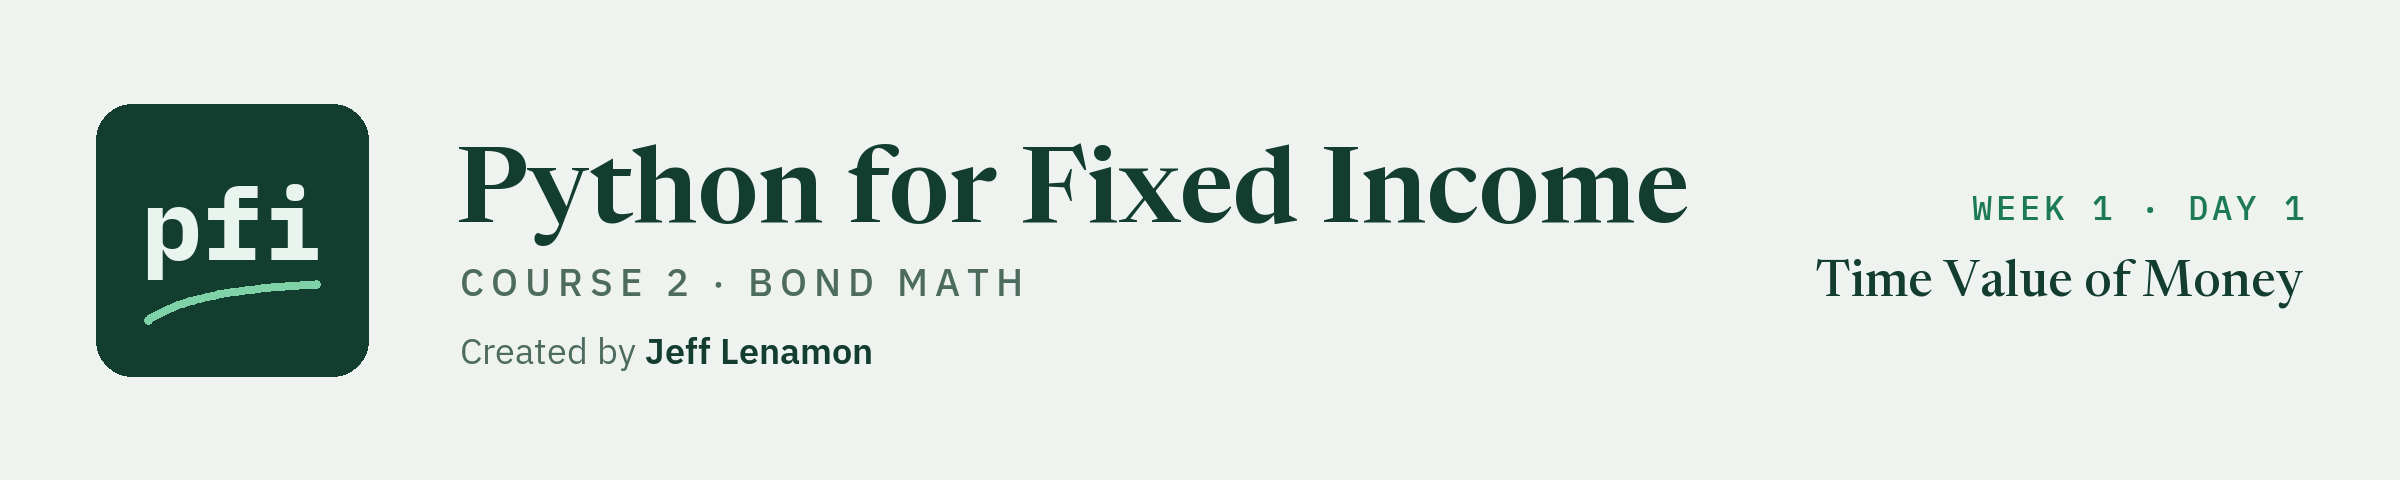

# Time Value of Money

Week 1, Day 1. What money due later is worth today, and what money today grows to: the first two functions of your own bond math module, tested against Excel and saved with Git.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week1/day1/01_time_value_of_money.ipynb)

On Wednesday 30 September 2026 the desk bought four new bonds on the day they were issued. The issuers are familiar from Course 1, and the bonds are new. Each pays a fixed coupon twice a year and repays 100 per 100 of face on 30 September of its final year.

This week turns a bond's yield into its price, and its price back into a yield. Every step rests on one idea, and today is about that idea alone: **a payment due later is worth less than the same payment today.** By how much depends on the rate, the time, and how often interest compounds.

Today you will:

1. Set up a work folder for the course's bond math.
2. Grow 100 at a bond's yield, half-year by half-year: future value.
3. Bring a bond's redemption back to today: present value and the discount factor.
4. Compare annual, semiannual, and quarterly compounding.
5. Write your first two functions into your own module, `bondmath.py`, docstring first.
6. Test them against Excel with pytest, and read a pass and a failure.
7. Save the day with Git, and take the module home to your own folder.

Course 2 keeps one rule throughout: **Excel is the answer key.** Every function you write is checked against numbers that Excel produced, kept in two reference files in the repo's `data` folder.

The issuers are invented. Every number here describes the data, and nothing says a bond or an issuer is good or bad.

## 1.1 Your Bond Math Workspace

In Course 1 every notebook wrote its files beside itself and deleted them at the end. Course 2 builds one module over fifteen days, tests it, and keeps it in Git, so it needs somewhere to live that is not the course's own folder. The first cell of every notebook in this course makes a fresh **work folder** in your computer's temp folder and moves into it. Everything the notebook writes goes there.

Q. Set up today's work folder and copy the Excel reference files into it.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_01_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_01_wohhn0c9, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


* The work folder's name starts with `pfi_course2_01_` and ends with eight random characters, so each run gets a new one. Only the name is printed: the full path includes your user name, and nothing in this course prints it.
* The data location is fixed before the notebook moves. On your own machine the files come from the repo's `data` folder, three levels up from this notebook. In Colab they come from GitHub.
* `bondmath_excel_reference_tvm.csv` holds the Excel numbers for week 1: every formula Excel was given, written out, and the value it returned. `bondmath_excel_reference.csv` is for week 2 on.
* pytest is the testing tool used from section 1.6. If it is missing, the cell stops with the line that installs it.

Q. Type in the four bonds.

In [2]:
bonds = pd.DataFrame({
    "cusip": ['99001BZA7', '99002CZA4', '99003DZA1', '99004EZA8'],
    "issuer": ['Quorvane Energy', 'Dunmarrow Rail', 'Pellwick Paper', 'Halvering Foods'],
    "ticker": ['QVNE', 'DNMR', 'PLWK', 'HLVF'],
    "rating": ['BBB', 'BB+', 'A-', 'B+'],
    "coupon_pct": [5.25, 6.125, 4.75, 7.5],
    "maturity": ['2031-09-30', '2033-09-30', '2029-09-30', '2036-09-30'],
    "years": [5, 7, 3, 10],
    "yield_pct": [5.4, 6.125, 4.6, 7.7],
})

bonds

,cusip,issuer,ticker,rating,coupon_pct,maturity,years,yield_pct
0,99001BZA7,Quorvane Energy,QVNE,BBB,5.250,2031-09-30,5,5.400
1,99002CZA4,Dunmarrow Rail,DNMR,BB+,6.125,2033-09-30,7,6.125
2,99003DZA1,Pellwick Paper,PLWK,A-,4.750,2029-09-30,3,4.600
3,99004EZA8,Halvering Foods,HLVF,B+,7.500,2036-09-30,10,7.700


* Each bond settles on 30 September 2026 and matures on 30 September a whole number of years later: Pellwick in 3 years, Quorvane in 5, Dunmarrow in 7, and Halvering in 10. Today is a coupon date, and every bond has a whole number of half-years left. That keeps week 1's arithmetic exact. Week 2 moves the settlement date between coupons.
* The CUSIPs are invented, in the range reserved for internal use, like every CUSIP in the course.

The course works in two units, and every function and every column keeps to them:

| What | Unit | Example |
| --- | --- | --- |
| Rates in: coupon, yield | percent a year | `coupon_pct` 5.25 means 5.25 percent of face a year |
| Money out: prices, present values | per 100 of face | a price of 98.50 is 98.50 for every 100 of face |

Excel's functions take rates as decimals. Every Excel formula in this course therefore divides by 100 in plain sight, `5.4/100`, so you can see the conversion each time.

Q. Quorvane's yield is 5.40 percent a year, compounded twice a year. What is the rate for one half-year, as Excel and the formulas below use it?

In [3]:
# the first row of the table is Quorvane
quorvane = bonds.iloc[0]

# percent to a decimal, then split across the two half-years of a year
rate_decimal = quorvane["yield_pct"] / 100
period_rate = rate_decimal / 2

print(f"{quorvane['issuer']}: {quorvane['yield_pct']:.2f} percent a year is {rate_decimal:.3f} as a decimal")
print(f"Rate for one half-year: {period_rate:.3f} as a decimal, {period_rate * 100:.2f} percent")

Quorvane Energy: 5.40 percent a year is 0.054 as a decimal
Rate for one half-year: 0.027 as a decimal, 2.70 percent


* 5.40 percent a year is 0.054 as a decimal, and 0.027 for each half-year: 2.70 percent.
* A yield compounded twice a year is applied as half the annual rate, twice a year. That is the convention for every bond in this course, and the one Excel's bond functions use when their frequency argument is 2.

## 1.2 Future Value

Put 100 to work at 5.40 percent a year, compounded twice a year. After six months it has earned half a year's interest, and from then on that interest earns interest too. **Future value** is what the 100 has grown to at the end.

Q. What is the 100 worth after one half-year?

In [4]:
amount = 100

# one half-year of interest at the half-year rate
after_one_period = amount * (1 + period_rate)

print(f"100 after one half-year: {after_one_period:.4f}")

100 after one half-year: 102.7000


* 102.7000: 100 plus 2.70 of interest.

Q. Follow the 100 through all ten half-years of Quorvane's five years.

In [5]:
value = amount
rows = []

# each half-year, the whole balance earns the half-year rate
for period in range(1, 11):
    value = value * (1 + period_rate)
    rows.append({"half_year": period, "years": period / 2, "value": round(value, 4)})

growth = pd.DataFrame(rows)
growth

,half_year,years,value
0,1,0.5,102.7000
1,2,1.0,105.4729
2,3,1.5,108.3207
3,4,2.0,111.2453
4,5,2.5,114.2490
5,6,3.0,117.3337
6,7,3.5,120.5017
7,8,4.0,123.7552
8,9,4.5,127.0966
9,10,5.0,130.5282


* The 100 grows to 130.5282 after ten half-years.
* Each step adds more than the one before: 2.70 in the first half-year, 3.4316 in the last. That is interest on interest. Simple interest at 5.40 percent would add 2.70 every time and end at 127.00.

Q. Get the same number with one line, from the formula.

In [6]:
# ten half-years: the half-year rate applied ten times
periods = 2 * 5
future_value = amount * (1 + period_rate) ** periods

# the loop above and the formula must agree
assert abs(future_value - value) < 1e-9, "the formula and the loop disagree"
print(f"Future value of 100 after 5 years at 5.40 percent, semiannual: {future_value:.4f}")

Future value of 100 after 5 years at 5.40 percent, semiannual: 130.5282


* 130.5282, the same as the loop. The formula is the loop written once: `amount x (1 + rate / frequency) ** (frequency x years)`.
* `**` is Python's power operator, as in Course 1. In Excel it is `^`.

**Excel side by side.** Two ways in a sheet, both tested in Excel:

* As a growth column: type 100 in A1, type `=A1*(1+5.4/100/2)` in A2, and fill A2 down to A11. A11 holds 130.5282261160894, the same as the loop.
* With Excel's function: `=FV(5.4/100/2,2*5,0,-100)` returns 130.5282261160894. The arguments are the rate per period, the number of periods, the payment each period (0 here: no coupons are being added), and the starting amount, entered as `-100`. With the 100 entered as negative, FV returns a positive number: Excel's time value functions give money paid in and money paid out opposite signs.

## 1.3 Present Value and Discount Factors

Turn the question round. Quorvane will repay 100 on 30 September 2031. What is that 100 worth on 30 September 2026, if money earns 5.40 percent a year, compounded twice a year? **Present value** is the amount that, invested today at that rate, would grow to the payment on the day it is due. It is future value run backwards: divide by the growth factor instead of multiplying.

Q. What is Quorvane's redemption worth today?

In [7]:
redemption = 100

# divide by the same growth factor that future value multiplies by
present_value = redemption / (1 + period_rate) ** periods

print(f"Quorvane's 100, due in 5 years, is worth {present_value:.4f} today at 5.40 percent, semiannual")

Quorvane's 100, due in 5 years, is worth 76.6118 today at 5.40 percent, semiannual


* 76.6118. Invested today at 5.40 percent, compounded twice a year, 76.6118 grows to exactly 100 in five years.

Q. Does growing the present value for five years give the 100 back?

In [8]:
# present value, grown forward again
grown_back = present_value * (1 + period_rate) ** periods

assert abs(grown_back - redemption) < 1e-9, "present value does not undo future value"
print(f"{present_value:.4f} grown for 5 years: {grown_back:.4f}")

76.6118 grown for 5 years: 100.0000


* 100.0000. Present value and future value undo each other. The test file in section 1.6 checks exactly this.

The number that turns 100 due later into its value today is the **discount factor**: the present value of 1. For Quorvane's five years at 5.40 percent it is 0.766118, so 100 due then is worth 76.6118 now. On day 2 every coupon of a bond gets its own discount factor, and the price is the sum.

Q. What is each bond's redemption worth today, at its own yield?

In [9]:
# for each bond: the discount factor at its yield and years, then the present value of its 100
bonds["discount_factor"] = 1 / (1 + bonds["yield_pct"] / 100 / 2) ** (2 * bonds["years"])
bonds["pv_of_redemption"] = 100 * bonds["discount_factor"]

bonds[["issuer", "years", "yield_pct", "discount_factor", "pv_of_redemption"]].round(4)

,issuer,years,yield_pct,discount_factor,pv_of_redemption
0,Quorvane Energy,5,5.400,0.7661,76.6118
1,Dunmarrow Rail,7,6.125,0.6555,65.5527
2,Pellwick Paper,3,4.600,0.8725,87.2461
3,Halvering Foods,10,7.700,0.4698,46.9753


* Pellwick's 100, due in 3 years at 4.60 percent, is worth 87.2461 today. Halvering's, due in 10 years at 7.70 percent, is worth 46.9753: less than half.
* Two things push a present value down: a higher rate and a longer wait. Halvering has both.
* The columns are computed for all four bonds at once, the way Course 1 computed a column from other columns in pandas.

**Excel side by side.** Two ways, both tested in Excel:

* The formula written out: `=100/(1+5.4/100/2)^(2*5)` returns 76.61178196895271.
* Excel's function: `=PV(5.4/100/2,2*5,0,100)` returns -76.61178196895271, with a minus sign. The 100 is money you receive later, so its value today comes back as money you would pay now: negative. This is the same sign convention as FV. A minus in front, `=-PV(5.4/100/2,2*5,0,100)`, gives 76.61178196895271. Your Python function returns the positive number, and its tests compare it with minus Excel's value.

## 1.4 Annual, Semiannual, and Quarterly Compounding

A rate of 5.40 percent a year can be applied once a year, twice, or four times. The more often interest is added, the sooner it starts earning interest of its own. The course's bonds pay twice a year and their yields are compounded twice a year, but you will meet the other two, and a yield is only complete with its frequency.

Q. Grow Quorvane's 100 and discount it, at 5.40 percent for 5 years, compounding once, twice, and four times a year.

In [10]:
rows = []
for frequency in [1, 2, 4]:
    # the rate for one period, and the number of periods, both depend on the frequency
    rate_per_period = 5.40 / 100 / frequency
    number_of_periods = frequency * 5
    growth_factor = (1 + rate_per_period) ** number_of_periods
    rows.append({
        "frequency": frequency,
        "periods": number_of_periods,
        "future_value": 100 * growth_factor,
        "present_value": 100 / growth_factor,
    })

compounding = pd.DataFrame(rows)
compounding.round(4)

,frequency,periods,future_value,present_value
0,1,5,130.0778,76.8771
1,2,10,130.5282,76.6118
2,4,20,130.7600,76.4760


* Compounded once a year, 100 grows to 130.0778. Twice a year, 130.5282. Four times, 130.7600.
* Present values move the other way: 76.8771, 76.6118, and 76.4760.
* Between annual and semiannual, the present value of the same 100 differs by 0.2653 per 100 of face. On 10,000,000 dollars of face that is 26,530.98 dollars, from the frequency alone.

Q. How much is that difference, as a share of the value?

In [11]:
annual = compounding.loc[compounding["frequency"] == 1, "present_value"].iloc[0]
semiannual = compounding.loc[compounding["frequency"] == 2, "present_value"].iloc[0]

# the gap in price points per 100, and as a percent of the semiannual value
gap_points = annual - semiannual
gap_percent = gap_points / semiannual * 100

print(f"Annual minus semiannual: {gap_points:.4f} per 100 of face, {gap_percent:.3f} percent of the value")

Annual minus semiannual: 0.2653 per 100 of face, 0.346 percent of the value


* 0.2653 points, or 0.346 percent. Small, and large enough to fail any test against Excel. Using the wrong frequency is a convention error: the code runs, the number looks reasonable, and it is wrong. The AI check at the end of this notebook is exactly that.

**Excel side by side.** The frequency appears twice in each formula, in the rate and in the number of periods. Annual: `=FV(5.4/100/1,1*5,0,-100)` returns 130.0777614445024 and `=PV(5.4/100/1,1*5,0,100)` returns -76.87709174074688. Quarterly: `=FV(5.4/100/4,4*5,0,-100)` returns 130.7600447631355 and `=PV(5.4/100/4,4*5,0,100)` returns -76.475960360173. Change the frequency in one place and not the other, and Excel computes a different number without complaint.

## 1.5 Your First Two Functions, Docstring First

In Course 1, notebook 19, you moved functions out of notebook cells into a module, a `.py` file, and imported it. Course 2 does the same with the bond math, from today to the last day. The module is called `bondmath.py`, it lives in the work folder, and it grows by one or two functions a day. By the end of week 3 it prices bonds, measures their risk, and runs a book's risk report.

Each function is written in a fixed order. **The docstring comes first.** Before any code, it says:

* the units of every input and of the result,
* the convention: here, how often interest compounds,
* the Excel formula that gives the same number.

A docstring like that is what you would give a colleague, or an AI assistant, as the request. If the code does not do what the docstring says, the docstring is the evidence.

Q. Write the top of the module and `future_value`. Read the cell before you run it.

In [12]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods

Writing bondmath.py


* `Writing bondmath.py`, and nothing ran: the cell saved a text file, as in Course 1.
* The file opens with a docstring for the whole module. It lists the units that every function in it keeps to, including some for later weeks.
* Two imports, `calendar` and `date`, are not used until week 2. They sit at the top from the start, so the top of the file never has to change.
* `future_value` stops on a frequency other than 1, 2, or 4 with a `ValueError`: a check that stops, from Course 1. Then it computes the rate per period and the number of periods, and grows the amount, the same steps as section 1.2.

Q. Add `present_value` to the end of the module.

In [13]:
%%writefile -a bondmath.py


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods

Appending to bondmath.py


* `Appending to bondmath.py`. `-a` adds to the end of the file, as in Course 1.
* The docstring says the function returns a positive number, and how that relates to Excel's negative PV. A reader does not have to discover the sign convention by surprise.

Q. Import the module.

In [14]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value']


* Two functions, in the order they were written. The imports `calendar` and `date` are in the module too, but they are not functions of `bondmath`, so they are not listed.
* The work folder is put first on `sys.path`, the list of folders Python searches for a module, so that `import bondmath` finds this file and no other.

Q. Do the functions give the numbers worked out by hand above?

In [15]:
fv = bondmath.future_value(100, 5.40, 5)
pv = bondmath.present_value(100, 5.40, 5)

# each must equal the number from the cells above
assert abs(fv - future_value) < 1e-9, "future_value differs from section 1.2"
assert abs(pv - present_value) < 1e-9, "present_value differs from section 1.3"

print(f"bondmath.future_value(100, 5.40, 5) = {fv:.4f}")
print(f"bondmath.present_value(100, 5.40, 5) = {pv:.4f}")

bondmath.future_value(100, 5.40, 5) = 130.5282
bondmath.present_value(100, 5.40, 5) = 76.6118


* 130.5282 and 76.6118, as before. The frequency was not given, so the default of 2 was used: semiannual.
* Notice the units in the call: 5.40, not 0.054. The function takes percent, as the docstring says, and divides by 100 itself.

Q. What does the function promise? Ask it.

In [16]:
help(bondmath.present_value)

Help on function present_value in module bondmath:

present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float
    Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)



* The signature, with its type hints, then the docstring word for word. Anyone who imports the module next month reads this and not the code.

Q. What happens when the frequency is one the course does not use, such as 12?

In [17]:
# try and except, from Course 1: catch the error and print its message
try:
    bondmath.future_value(100, 5.40, 5, frequency=12)
except ValueError as error:
    print(f"ValueError: {error}")

ValueError: frequency must be 1, 2, or 4, not 12


* `ValueError: frequency must be 1, 2, or 4, not 12`. The function refuses rather than guessing. A monthly frequency would compute a number, and nothing about that number would say the bond does not pay monthly.
* The error is caught here so the message prints cleanly. Without `try`, the cell would stop with a traceback, and the notebook would stop with it.

Q. Use the function on all four bonds.

In [18]:
# one call for each bond, in table order, with its own yield and years
bonds["pv_from_module"] = [bondmath.present_value(100, y, t) for y, t in zip(bonds["yield_pct"], bonds["years"])]

# the module must agree with the column computed in section 1.3
assert (bonds["pv_from_module"] - bonds["pv_of_redemption"]).abs().max() < 1e-9
bonds[["issuer", "years", "yield_pct", "pv_of_redemption", "pv_from_module"]].round(4)

,issuer,years,yield_pct,pv_of_redemption,pv_from_module
0,Quorvane Energy,5,5.400,76.6118,76.6118
1,Dunmarrow Rail,7,6.125,65.5527,65.5527
2,Pellwick Paper,3,4.600,87.2461,87.2461
3,Halvering Foods,10,7.700,46.9753,46.9753


* The same four present values. The list comprehension calls the function once for each row, with that row's yield and years, the pattern from Course 1. From week 2 the course applies its functions to the 200 bonds of the holdings file the same way.

## 1.6 Testing with pytest

An `assert` in a notebook checks a function once, today. A **test** is an `assert` kept in a file of its own, so it can be run again every time the module changes. In Course 1, notebook 19, you put asserts in a function whose name started with `test_`. pytest is the tool that finds every such function in every file whose name starts with `test_`, runs them all, and reports.

The course's test file is `test_bondmath.py`. Its tests read the expected numbers from Excel's reference file, never from the code they test. If the module and Excel disagree, a test fails.

Q. Write the top of the test file and the first test. Read it before you run it.

In [19]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]

Writing test_bondmath.py


* `read_rows` reads a reference CSV from the test file's own folder into a list of dictionaries, one for each row, with `csv.DictReader`. Every value is text, so each test turns what it needs into a number with `float` or `int`.
* `tvm_rows("FV")` keeps the rows for one Excel function, and stops with a message if there are none, so a test can never pass by checking nothing.
* `test_future_value_matches_excel_fv` loops over every FV row and asserts that `future_value` agrees with Excel to 0.000001. `pytest.approx` makes that comparison, and `row["case_id"]` after the comma names the row in a failure message.
* `math` and `date` are imported for tests of later weeks, like the module's own early imports.

Q. Add the other two tests.

In [20]:
%%writefile -a test_bondmath.py


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)

Appending to test_bondmath.py


* `test_present_value_matches_excel_pv` compares with **minus** Excel's PV, because of Excel's sign convention.
* `test_present_value_undoes_future_value` needs no Excel at all: grow 100, discount it back, and get 100, at every frequency. Section 1.3 checked this once.

Q. Run the tests.

In [21]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...                                                                      [100%]
3 passed in 0.01s



* Three dots and `3 passed`. Each dot is a test that passed. The time at the end changes from run to run.
* `subprocess.run` runs another program from Python, waits for it, and hands back what it printed, which the cell prints. The program here is the command `python -m pytest -q -p no:cacheprovider`, one part at a time:
  * `sys.executable` is the Python this notebook runs on, so pytest uses the same Python and the same packages.
  * `-m pytest` runs pytest as a program. `-q` keeps the report short. `-p no:cacheprovider` stops pytest leaving a cache folder behind.
  * `cwd=work` runs it inside the work folder, where the test file is.
* pytest runs in a fresh process, so it imports `bondmath.py` as the file is now, not the copy this notebook imported earlier.
* In your own terminal, in your own folder, the same thing is `python -m pytest`. The notebook runs it every day with this same cell.

Q. How many Excel numbers did those three tests check?

In [22]:
# the same reference file the tests read, loaded with pandas
tvm = pd.read_csv("bondmath_excel_reference_tvm.csv")

print(f"FV rows checked: {(tvm['function'] == 'FV').sum()}")
print(f"PV rows checked: {(tvm['function'] == 'PV').sum()}")
tvm.loc[tvm["function"] == "PV", ["case_id", "amount", "rate_pct", "years", "frequency", "excel_formula", "excel_value"]].head(3)

FV rows checked: 18
PV rows checked: 18


,case_id,amount,rate_pct,years,frequency,excel_formula,excel_value
18,tvm_pv_01,100.0,5.0,3.0,2,"=PV(5/100/2,2*3,0,100)",-86.229687
19,tvm_pv_02,100.0,5.0,3.0,1,"=PV(5/100/1,1*3,0,100)",-86.383760
20,tvm_pv_03,100.0,5.0,3.0,4,"=PV(5/100/4,4*3,0,100)",-86.150860


* 18 FV rows and 18 PV rows, from 0.5 to 30 years and from 0.5 to 8.6 percent, at all three frequencies, including Quorvane's 100 at 5.40 percent. Each row has the exact formula Excel was given and the value it returned.

Now a failing test. A colleague writes a quick test for Quorvane's present value and compares it with Excel's PV exactly as Excel returns it.

Q. What does a failure look like? Write the colleague's test in a file of its own and run pytest on that file only.

In [23]:
%%writefile test_excel_sign.py
"""A test written the wrong way on purpose: it compares with Excel's PV exactly as Excel returns it."""
import csv
from pathlib import Path

import pytest

import bondmath


def test_present_value_equals_excel_pv_as_returned():
    with open(Path(__file__).parent / "bondmath_excel_reference_tvm.csv", newline="", encoding="utf-8") as f:
        row = [r for r in csv.DictReader(f) if r["case_id"] == "tvm_pv_09"][0]
    # Quorvane's 100 at 5.40 percent for 5 years, semiannual
    assert bondmath.present_value(100, 5.4, 5) == pytest.approx(float(row["excel_value"]), abs=1e-6)

Writing test_excel_sign.py


In [24]:
# run one test file only, by naming it
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_excel_sign.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

F                                                                        [100%]
================================== FAILURES ===================================
_______________ test_present_value_equals_excel_pv_as_returned ________________

    def test_present_value_equals_excel_pv_as_returned():
        with open(Path(__file__).parent / "bondmath_excel_reference_tvm.csv", newline="", encoding="utf-8") as f:
            row = [r for r in csv.DictReader(f) if r["case_id"] == "tvm_pv_09"][0]
        # Quorvane's 100 at 5.40 percent for 5 years, semiannual
>       assert bondmath.present_value(100, 5.4, 5) == pytest.approx(float(row["excel_value"]), abs=1e-6)
E       assert 76.61178196895271 == -76.61178196895273 ± 1.0e-06
E         
E         comparison failed
E         Obtained: 76.61178196895271
E         Expected: -76.61178196895273 ± 1.0e-06

test_excel_sign.py:14: AssertionError
=========================== short test summary info ===========================
FAILED test_excel_sign.p

* `F` instead of a dot, and `1 failed`. Read a failure from the bottom up.
* The last line names the file, the test, and the comparison that failed. Above it, the line marked `>` is the assert, and the line marked `E` gives the two numbers: the function returned 76.6118 and the test expected -76.6118.
* The numbers are the same apart from the sign, so the function is right and the test is wrong. Excel's PV is negative by its sign convention, and `test_bondmath.py` already compares with minus Excel's value for this reason. A failing test says that two things disagree. Deciding which one is wrong is your job.
* The output shows file names and line numbers, never a full path, because pytest runs inside the work folder.

Q. Delete the colleague's file, so the work folder holds only the course's files.

In [25]:
# os.remove deletes a file
os.remove("test_excel_sign.py")

print(f"test_excel_sign.py exists: {os.path.exists('test_excel_sign.py')}")
print(f"Files in the work folder: {sorted(os.listdir(work))}")

test_excel_sign.py exists: False
Files in the work folder: ['__pycache__', 'bondmath.py', 'bondmath_excel_reference.csv', 'bondmath_excel_reference_tvm.csv', 'test_bondmath.py']


* The two reference CSVs, `bondmath.py`, `test_bondmath.py`, and a folder called `__pycache__`, where Python keeps compiled copies of the modules it imports. Week 2 tells Git to ignore that folder. Leave it alone.

## Excel Side by Side

Every number in this notebook has an Excel twin, and the reference file holds them. Here they are in one place.

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| Grow 100 for 5 years at 5.40 percent, semiannual | `bondmath.future_value(100, 5.40, 5)` | `=FV(5.4/100/2,2*5,0,-100)` | 130.5282261160894 |
| The same, as a growth column | the loop in 1.2 | 100 in A1, `=A1*(1+5.4/100/2)` in A2 filled down to A11 | 130.5282261160894 in A11 |
| The same, written out | `100 * (1 + 0.054 / 2) ** 10` | `=100*(1+5.4/100/2)^(2*5)` | 130.5282261160894 |
| Discount 100 due in 5 years | `bondmath.present_value(100, 5.40, 5)` | `=PV(5.4/100/2,2*5,0,100)` | -76.61178196895271 |
| The same, positive | the same | `=-PV(5.4/100/2,2*5,0,100)` | 76.61178196895271 |
| The same, written out | `100 / (1 + 0.054 / 2) ** 10` | `=100/(1+5.4/100/2)^(2*5)` | 76.61178196895271 |
| Annual compounding | `frequency=1` | `=PV(5.4/100/1,1*5,0,100)` | -76.87709174074688 |
| Quarterly compounding | `frequency=4` | `=PV(5.4/100/4,4*5,0,100)` | -76.475960360173 |

To try it: open a blank sheet, type `=FV(5.4/100/2,2*5,0,-100)` into a cell, and widen the column until you see the decimals. Then type `=PV(5.4/100/2,2*5,0,100)` into the next cell and note the minus sign. FV and PV take the same four arguments in the same order: the rate per period, the number of periods, the payment each period, and the amount at the other end.

Q. Does `bondmath` agree with Excel on every FV and PV row of the reference file?

In [26]:
rows = []
for row in tvm[tvm["function"].isin(["FV", "PV"])].itertuples():
    if row.function == "FV":
        python_value = bondmath.future_value(row.amount, row.rate_pct, row.years, row.frequency)
        excel_value = row.excel_value
    else:
        python_value = bondmath.present_value(row.amount, row.rate_pct, row.years, row.frequency)
        # Excel's PV carries a minus sign
        excel_value = -row.excel_value
    rows.append({"case_id": row.case_id, "excel_formula": row.excel_formula,
                 "excel": excel_value, "python": python_value, "gap": abs(python_value - excel_value)})

answer_key = pd.DataFrame(rows)
assert answer_key["gap"].max() < 1e-6, "a row differs from Excel"
print(f"Rows compared: {len(answer_key)}, largest gap: {answer_key['gap'].max():.1e}")

# the rows for today's four bonds, and Quorvane at the other two frequencies
answer_key[answer_key["case_id"].isin(["tvm_pv_09", "tvm_pv_10", "tvm_pv_11", "tvm_pv_12", "tvm_pv_17", "tvm_pv_18"])]

Rows compared: 36, largest gap: 1.4e-09


,case_id,excel_formula,excel,python,gap
26,tvm_pv_09,"=PV(5.4/100/2,2*5,0,100)",76.611782,76.611782,1.421085e-14
27,tvm_pv_10,"=PV(6.125/100/2,2*7,0,100)",65.552699,65.552699,1.421085e-14
28,tvm_pv_11,"=PV(4.6/100/2,2*3,0,100)",87.246135,87.246135,0.000000e+00
29,tvm_pv_12,"=PV(7.7/100/2,2*10,0,100)",46.975345,46.975345,3.552714e-14
34,tvm_pv_17,"=PV(5.4/100/1,1*5,0,100)",76.877092,76.877092,0.000000e+00
35,tvm_pv_18,"=PV(5.4/100/4,4*5,0,100)",76.475960,76.475960,5.684342e-14


* All 36 rows agree, and the largest gap is far below the course's tolerance of 0.000001 for a price per 100. The test file runs this comparison every time you run pytest.
* The four running bonds are rows 09 to 12 of PV. Pellwick, the shortest, keeps the most of its 100; Halvering, the longest, the least.

## Save the Day with Git

You now have a module and a test file that pass. Tomorrow you will add to both. **Git** keeps a record of every version of the files in a folder: each saved version is a **commit**, with a message saying what changed. With that record, any change can be reviewed line by line and any mistake undone. In this course Git is your undo button.

**Installing Git.** Colab has Git already. On Windows, install Git for Windows from [git-scm.com/downloads](https://git-scm.com/downloads) with the default choices, or run `winget install --id Git.Git` in PowerShell where your firm allows it. On a work machine, follow your firm's policy on installing software. Restart VS Code afterwards, so it finds Git.

**One rule in the notebook.** This notebook runs inside the course's own folder, which is itself a Git repository. So every Git command here is written `git -C "{work}" ...`: `-C` tells Git which folder to act on, and `{work}` is the work folder. Git never acts on the course's folder from here. In your own terminal, inside your own folder, you type the same commands without `-C`: plain `git status`.

Q. Is Git installed? If it is, make the work folder a repository, and give it a name and an email for its commits.

In [27]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [28]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course2_01_wohhn0c9 and nowhere else


* The first line is Git's version. Yours may differ.
* `init -q -b main` makes the work folder a repository, quietly, with its first branch called `main`. It creates a hidden `.git` folder inside the work folder, where the record is kept.
* Every commit carries a name and an email. These four settings apply to this repository only: a course name, an address at `example.com` (a domain reserved for examples), line endings left as written, and no commit signing. Nothing here touches your own Git settings.
* The guard asked Git where the top of this repository is and checked that the answer is the work folder. If it were anything else, the `assert` would have stopped the notebook here.

Q. What does Git see in the folder?

In [29]:
!git -C "{work}" status

On branch main

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	__pycache__/
	bondmath.py
	bondmath_excel_reference.csv
	bondmath_excel_reference_tvm.csv
	test_bondmath.py

nothing added to commit but untracked files present (use "git add" to track)


* `No commits yet`, and four **untracked** items: Git sees them but is not keeping a record of them.
* You decide what goes into a commit. Today it is the two files you wrote. The reference CSVs come from the course repo and are not yours to change, and `__pycache__` is Python's own.

Q. Choose the two files for the first commit, and look again.

In [30]:
# git add chooses files for the next commit
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" status

On branch main

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   bondmath.py
	new file:   test_bondmath.py

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	__pycache__/
	bondmath_excel_reference.csv
	bondmath_excel_reference_tvm.csv



* The two files are now listed under `Changes to be committed`. Choosing them is called **staging**. The other two items are still untracked.

Q. Make the first commit.

In [31]:
# a commit saves the staged files, with a message that says what changed
!git -C "{work}" commit -m "Add future_value and present_value, tested against Excel FV and PV"

[main (root-commit) ea0b54d] Add future_value and present_value, tested against Excel FV and PV
 2 files changed, 109 insertions(+)
 create mode 100644 bondmath.py
 create mode 100644 test_bondmath.py


* The first line has the branch, `root-commit` because it is the first, a short **commit hash** (the commit's name, different on every run), and the message. Then the count: 2 files, and every line in them added.
* The message says what the commit does. Tomorrow's commit will be a small change, and its message will say which one.

Q. What is left?

In [32]:
!git -C "{work}" status

On branch main


Untracked files:
  (use "git add <file>..." to include in what will be committed)
	__pycache__/
	bondmath_excel_reference.csv
	bondmath_excel_reference_tvm.csv

nothing added to commit but untracked files present (use "git add" to track)


* Only the reference CSVs and `__pycache__`, still untracked. Everything you wrote today is in the record.

## Bring It Home

The work folder is a scratch space, and the notebook makes a new one every time it runs. Your own copy of the module lives in a folder of yours: `my_bondmath`, in your `projects` folder beside the course repo. No notebook ever touches it. Every day of this course ends by bringing that day's work into it.

Today you create the folder and make its first commit. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active, as in Course 1. Each step below shows what to type, then what you should see.

**Step 1.** Make the folder and go into it. It is not called `bondmath`, so that it can never be mistaken for the module itself.

```powershell
New-Item -ItemType Directory -Force "$HOME\projects\my_bondmath" | Out-Null
Set-Location "$HOME\projects\my_bondmath"
```

**Step 2.** Copy the two reference files from the course repo's `data` folder.

```powershell
Copy-Item "$HOME\projects\python-fixed-income\data\bondmath_excel_reference.csv" .
Copy-Item "$HOME\projects\python-fixed-income\data\bondmath_excel_reference_tvm.csv" .
```

**Step 3.** Copy today's two files from the work folder. Use the folder name the setup cell printed in place of `pfi_course2_01_xxxxxxxx`.

```powershell
Copy-Item "$env:TEMP\pfi_course2_01_xxxxxxxx\bondmath.py" .
Copy-Item "$env:TEMP\pfi_course2_01_xxxxxxxx\test_bondmath.py" .
Get-ChildItem -Name
```

```
bondmath.py
bondmath_excel_reference.csv
bondmath_excel_reference_tvm.csv
test_bondmath.py
```

To look inside the work folder first, `explorer "$env:TEMP\pfi_course2_01_xxxxxxxx"` opens it in File Explorer.

**Step 4.** Run the tests in your folder.

```powershell
python -m pytest -q
```

```
...                                                                      [100%]
3 passed in 0.05s
```

**Step 5.** Make the folder a repository, set your name and email for it, and make the first commit. Use your own name and email: they are stored in each commit.

```powershell
git --version
git init -q -b main
git config user.name "Your Name"
git config user.email "you@example.com"
git add bondmath.py test_bondmath.py
git commit -m "Add future_value and present_value, tested against Excel FV and PV"
git status
```

```
[main (root-commit) 1a2b3c4] Add future_value and present_value, tested against Excel FV and PV
 2 files changed, 109 insertions(+)
 create mode 100644 bondmath.py
 create mode 100644 test_bondmath.py
```

The output above is the commit's. The version line and the hash will differ. `git status` then lists the two CSVs and `__pycache__/` as untracked, as in the notebook. `-q` keeps `init` quiet: without it, `init` prints the full path of the folder, user name and all.

**In Colab**, open the file browser on the left, find the work folder under `/tmp`, and download `bondmath.py` and `test_bondmath.py` (right-click, Download). The downloaded files are your copy. Do steps 1 to 5 on your own machine when you can.

**If Git is blocked** on your work laptop, read the saved output above, and do step 5 at home or skip it. Nothing outside the Git sections depends on Git.

From tomorrow, Bring It Home is shorter: you paste the day's new functions and tests at the end of your two files, run the tests, read `git diff`, and commit.

## You Can Now

* Grow an amount with periodic compounding, step by step and with one formula: future value.
* Bring a payment back to today with a discount factor: present value.
* Say why the frequency matters, and spot a number computed with the wrong one.
* Write a function docstring first: units, convention, and the Excel formula.
* Keep functions in your own module, `bondmath.py`, and import it.
* Write tests that read Excel's numbers, run them with pytest, and read a pass and a failure.
* Use Excel's FV and PV with their sign convention, and write the discount out by hand.
* Make a Git repository and a first commit, and set up your own `my_bondmath` folder.

Tomorrow, day 2, a bond becomes a list of cash flows, each with its own discount factor, and its price is their sum.

## Exercises

The exercises use a second set of four new bonds, bought on 30 September 2026 like the first four. The issuers are invented, and every answer describes the data.

Replace each `...` with your own code, then run the check cell. Print the numbers you rely on with f-strings. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It types in the second set of bonds and defines `check`, a small function that marks your answers.

In [33]:
exercise_bonds = pd.DataFrame({
    "cusip": ['99005FZA4', '99007HZA8', '99008IZA5', '99009JZA2'],
    "issuer": ['Ostrevale Telecom', 'Tarnwick Utilities', 'Osmere Chemicals', 'Calderby Retail'],
    "ticker": ['OSTV', 'TRNW', 'OSMC', 'CLDB'],
    "rating": ['BBB-', 'A', 'BBB-', 'B'],
    "coupon_pct": [5.625, 4.375, 5.0, 8.25],
    "maturity": ['2030-09-30', '2028-09-30', '2032-09-30', '2034-09-30'],
    "years": [4, 2, 6, 8],
    "yield_pct": [5.8, 4.3, 5.35, 8.6],
})


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


exercise_bonds

,cusip,issuer,ticker,rating,coupon_pct,maturity,years,yield_pct
0,99005FZA4,Ostrevale Telecom,OSTV,BBB-,5.625,2030-09-30,4,5.80
1,99007HZA8,Tarnwick Utilities,TRNW,A,4.375,2028-09-30,2,4.30
2,99008IZA5,Osmere Chemicals,OSMC,BBB-,5.000,2032-09-30,6,5.35
3,99009JZA2,Calderby Retail,CLDB,B,8.250,2034-09-30,8,8.60


### Exercise 1

Q. With `bondmath.present_value`, find what each bond's 100 of redemption is worth today, at its own yield, compounded semiannually. Store Osmere's in **ex1_osmere**, unrounded, and the ticker of the bond whose redemption is worth least today in **ex1_lowest**.

In [34]:
ex1_osmere = ...
ex1_lowest = ...

In [35]:
check("Exercise 1 Osmere", ex1_osmere, 72.84897770986194)
check("Exercise 1 lowest", ex1_lowest, "CLDB")

Exercise 1 Osmere: not attempted yet
Exercise 1 lowest: not attempted yet


### Exercise 2

Q. Build a ladder of discount factors: one row for every half-year from 0.5 to 5.0 years, one column for each bond's ticker, and in each cell the discount factor at that bond's yield, semiannual. Store the table in **ex2_ladder**, its number of rows in **ex2_rows**, and Calderby's discount factor at 5 years, unrounded, in **ex2_cldb_5y**.

In [36]:
ex2_ladder = ...
ex2_rows = ...
ex2_cldb_5y = ...

In [37]:
check("Exercise 2 rows", ex2_rows, 10)
check("Exercise 2 Calderby at 5 years", ex2_cldb_5y, 0.6563823821846481)

Exercise 2 rows: not attempted yet
Exercise 2 Calderby at 5 years: not attempted yet


### Exercise 3

Q. The desk has 1,000,000 dollars to place for Tarnwick's 2 years at 4.30 percent a year. How many more dollars does it end with if the rate compounds quarterly rather than annually? Store the difference in dollars, unrounded, in **ex3_difference**.

In [38]:
ex3_difference = ...

In [39]:
check("Exercise 3 difference", ex3_difference, 1457.2615362685174)

Exercise 3 difference: not attempted yet


### Exercise 4

Q. Add a function to your module. `discount_factor(rate_pct, years, frequency=2)` returns the value today of 1 due in `years`. Write the docstring first: units, convention, and the Excel formula. Then add a test to `test_bondmath.py`, called `test_discount_factor_matches_excel_pv`, that checks it against every PV row of the reference file. Run pytest, and store `bondmath.discount_factor(5.35, 6)` in **ex4_value**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [40]:
%%writefile -a bondmath.py


# Exercise 4: write discount_factor(rate_pct, years, frequency=2) below this line

Appending to bondmath.py


In [41]:
%%writefile -a test_bondmath.py


# Exercise 4: write test_discount_factor_matches_excel_pv() below this line

Appending to test_bondmath.py


In [42]:
# run pytest, reload the module, then call your function
ex4_value = ...

In [43]:
check("Exercise 4 discount factor", ex4_value, 0.7284897770986194)

Exercise 4 discount factor: not attempted yet


### Exercise 5: AI check

You ask an AI assistant to write `present_value` for you, and you give it the docstring as the request. In this course **the docstring is the prompt.** This is what you gave it:

```
Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
Returns a positive number for a positive amount. Excel's PV returns the same number with a
minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, it returns a reasonable number, and it contains one bug: a convention error.

In [44]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def assistant_present_value(amount, rate_pct, years, frequency=2):
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
Returns a positive number for a positive amount. Excel's PV returns the same number with a
minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # discount the amount back to today
    return amount / (1 + rate_pct / 100) ** years

Q. Before you run the next cell: the docstring says semiannual compounding. What should the function return for Quorvane's 100, due in 5 years at 5.40 percent? Section 1.3 has the number.

In [45]:
print(f"Quorvane's 100 from the assistant's function: {assistant_present_value(100, 5.40, 5):.4f}")

Quorvane's 100 from the assistant's function: 76.8771


Q. The number is close, and close is not enough. Test the function against every PV row of Excel's reference file before you trust it.

In [46]:
# the test, written from Excel's reference rows before the code is trusted
tvm = pd.read_csv("bondmath_excel_reference_tvm.csv")
pv_rows = tvm[tvm["function"] == "PV"]

for row in pv_rows.itertuples():
    result = assistant_present_value(row.amount, row.rate_pct, row.years, row.frequency)
    # Excel's PV is negative, so the function should return minus the Excel value
    assert abs(result + row.excel_value) < 1e-6, f"{row.case_id}: {result:.6f} against Excel's {-row.excel_value:.6f}"

print(f"All {len(pv_rows)} PV rows match Excel")

AssertionError: tvm_pv_01: 86.383760 against Excel's 86.229687

Q. The test stops on the first row that disagrees. Read its message, find the convention the code broke, and fix the function in the cell that defines it. Run that cell and the test again until the test prints that every row matches. Then store `assistant_present_value(100, 5.40, 5)` in **ex5_quorvane** and the number of PV rows the test checked in **ex5_rows**.

In [47]:
# fix the function above and run the test again, then store the two answers
ex5_quorvane = ...
ex5_rows = ...

In [48]:
check("Exercise 5 Quorvane", ex5_quorvane, 76.61178196895271)
check("Exercise 5 rows checked", ex5_rows, 18)

Exercise 5 Quorvane: not attempted yet
Exercise 5 rows checked: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```